<a href="https://colab.research.google.com/github/REV-Prog-Lin-GESTAO-FLORESTAL/Revisao-Gestao-Florestal/blob/main/Codigos_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Código Python para Modelagem Multi-objetivo.

In [10]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 56.9 MB/s eta 0:00:00


Restricted license - for non-production use only - expires 2027-11-29
Economic Boundaries: Min = 11823.16, Max = 13399.61
Environmental Boundaries: Min = 5070.32, Max = 10845.99
-------------------------------------------------------
 Lambda |      Net Income | Environmental Impact
-------------------------------------------------------
   0.00 |        11823.16 |              5070.32
   0.10 |        11823.16 |              5070.32
   0.20 |        11823.16 |              5070.32
   0.30 |        12122.75 |              5440.73
   0.40 |        12122.75 |              5440.73
   0.50 |        12122.75 |              5440.73
   0.60 |        13399.61 |             10845.99
   0.70 |        13399.61 |             10845.99
   0.80 |        13399.61 |             10845.99
   0.90 |        13399.61 |             10845.99
   1.00 |        13399.61 |             10845.99


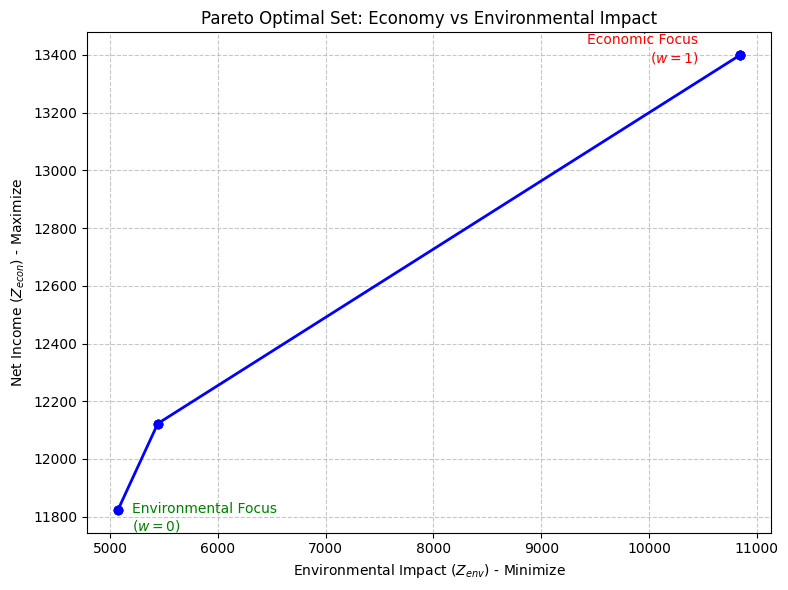

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# --- Problem Data ---
strata = ['E1', 'E2', 'E3', 'E4', 'E5']

data = {
    'max_area': {'E1': 21.66, 'E2': 14.17, 'E3': 11.33, 'E4': 6.34, 'E5': 7.53},
    'net_income': {'E1': 404.40, 'E2': 286.50, 'E3': 183.30, 'E4': 102.57, 'E5': 127.00},
    'firewood_yield': {'E1': 50.57, 'E2': 53.08, 'E3': 43.09, 'E4': 40.71, 'E5': 38.69},
    'stakes_yield': {'E1': 0, 'E2': 0, 'E3': 0, 'E4': 0, 'E5': 0},
    'labor': {'E1': 67.5, 'E2': 68.3, 'E3': 58.0, 'E4': 56.5, 'E5': 48.6},
    'truckload': {'E1': 6.7, 'E2': 6.3, 'E3': 4.8, 'E4': 4.5, 'E5': 5.6}
}

sensitivity = {'E1': 500, 'E2': 0.9, 'E3': 0.6, 'E4': 0.5, 'E5': 0.4}

constraints = {
    'fw_min': 2300,
    'labor_max': 3500,
    'stakes_min': 0,
    'truckload_max': 310,
    'max_sensitive_area': 25,
    'total_farm_area': 460,
    'preservation_prop': 0.2
}

# --- Auxiliary Functions ---

def add_constraints(model, E):
    """Centralizes constraint addition for reuse."""
    for j in strata:
        model.addConstr(E[j] <= data['max_area'][j], name=f"Area_Limit_{j}")

    if constraints.get('fw_min', 0) > 0:
        model.addConstr(gp.quicksum(data['firewood_yield'][j] * E[j] for j in strata) >= constraints['fw_min'], name="Min_Firewood")

    if constraints.get('labor_max', 0) > 0:
        model.addConstr(gp.quicksum(data['labor'][j] * E[j] for j in strata) <= constraints['labor_max'], name="Max_Labor")

    if constraints.get('truckload_max', 0) > 0:
        model.addConstr(gp.quicksum(data['truckload'][j] * E[j] for j in strata) <= constraints['truckload_max'], name="Truckload_Year")

    if constraints.get('max_sensitive_area', 0) > 0:
        model.addConstr(E['E1'] + E['E2'] <= constraints['max_sensitive_area'], name="Max_Sensitive_Area")

    if constraints.get('total_farm_area', 0) > 0 and constraints.get('preservation_prop', 0) > 0:
        max_area = constraints['total_farm_area'] * (1 - constraints['preservation_prop'])
        model.addConstr(gp.quicksum(E[j] for j in strata) <= max_area, name="Max_Total_Area")

def calculate_ideal_nadir_points(var_type='Continuous'):
    """Calculates the boundaries (minimum and maximum) of each objective function independently."""
    cat = GRB.INTEGER if var_type == 'Integer' else GRB.CONTINUOUS

    # 1. Maximize Income (Economic)
    m1 = gp.Model()
    m1.Params.OutputFlag = 0
    E1 = m1.addVars(strata, lb=0, vtype=cat)
    z_econ1 = gp.quicksum(data['net_income'][j] * E1[j] for j in strata)
    z_env1  = gp.quicksum(sensitivity[j] * E1[j] for j in strata)
    add_constraints(m1, E1)
    m1.setObjective(z_econ1, GRB.MAXIMIZE)
    m1.optimize()
    if m1.Status != GRB.OPTIMAL:
        raise Exception("Infeasible problem when maximizing economy.")

    z_econ_max = z_econ1.getValue()
    z_env_nadir = z_env1.getValue() # Impact generated when profit is maximum

    # 2. Minimize Environmental Impact
    m2 = gp.Model()
    m2.Params.OutputFlag = 0
    E2 = m2.addVars(strata, lb=0, vtype=cat)
    z_econ2 = gp.quicksum(data['net_income'][j] * E2[j] for j in strata)
    z_env2  = gp.quicksum(sensitivity[j] * E2[j] for j in strata)
    add_constraints(m2, E2)
    m2.setObjective(z_env2, GRB.MINIMIZE)
    m2.optimize()
    if m2.Status != GRB.OPTIMAL:
        raise Exception("Infeasible problem when minimizing impact.")

    z_env_min = z_env2.getValue()
    z_econ_min = z_econ2.getValue() # Profit generated when impact is minimum

    return z_econ_min, z_econ_max, z_env_min, z_env_nadir

def multiobjective_model(lambda_val, boundaries, var_type='Continuous'):
    z_econ_min, z_econ_max, z_env_min, z_env_max = boundaries

    model = gp.Model("Normalized_Multiobjective")
    model.Params.OutputFlag = 0

    cat = GRB.INTEGER if var_type == 'Integer' else GRB.CONTINUOUS
    E = model.addVars(strata, lb=0, vtype=cat, name="Area")

    # Original expressions
    z_econ = gp.quicksum(data['net_income'][j] * E[j] for j in strata)
    z_env = gp.quicksum(sensitivity[j] * E[j] for j in strata)

    # Normalization denominators (prevention against division by zero)
    den_econ = (z_econ_max - z_econ_min) if (z_econ_max - z_econ_min) != 0 else 1.0
    den_env = (z_env_max - z_env_min) if (z_env_max - z_env_min) != 0 else 1.0

    # Normalized functions [0, 1]
    z_econ_norm = (z_econ - z_econ_min) / den_econ
    z_env_norm = (z_env - z_env_min) / den_env

    # Maximize: Lambda * (Normalized Economy) - (1-Lambda) * (Normalized Impact)
    model.setObjective(lambda_val * z_econ_norm - (1 - lambda_val) * z_env_norm, GRB.MAXIMIZE)

    add_constraints(model, E)
    model.optimize()

    if model.Status == GRB.OPTIMAL:
        return z_econ.getValue(), z_env.getValue(), [E[j].X for j in strata]
    return None, None, None

# --- Execution and Frontier Plotting ---

variable_type = 'Continuous' # Change to 'Integer' if necessary

# 1. Obtain boundaries for normalization
boundaries = calculate_ideal_nadir_points(var_type=variable_type)
print(f"Economic Boundaries: Min = {boundaries[0]:.2f}, Max = {boundaries[1]:.2f}")
print(f"Environmental Boundaries: Min = {boundaries[2]:.2f}, Max = {boundaries[3]:.2f}")
print("-" * 55)
print(f"{'Weight':>7} | {'Net Income':>15} | {'Environmental Impact':>20}")
print("-" * 55)

econ_points = []
env_points = []

# 2. Sweep Lambda values
for i in range(11):
    lambda_val = i / 10
    z_e, z_a, areas = multiobjective_model(lambda_val, boundaries, var_type=variable_type)

    if z_e is not None and z_a is not None:
        print(f"{lambda_val:>7.2f} | {z_e:>15.2f} | {z_a:>20.2f}")
        econ_points.append(z_e)
        env_points.append(z_a)

# 3. Generate Pareto Chart
plt.figure(figsize=(8, 6))
plt.plot(env_points, econ_points, marker='o', linestyle='-', color='b', linewidth=2, markersize=6)

# Annotations for clarity
plt.title('Pareto Optimal Set: Economy vs Environmental Impact', fontsize=12)
plt.xlabel('Environmental Impact ($Z_{env}$) - Minimize', fontsize=10)
plt.ylabel('Net Income ($Z_{econ}$) - Maximize', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight extremes
if env_points:
    plt.annotate('Environmental Focus\n($w=0$)',
                 xy=(env_points[0], econ_points[0]), xytext=(10, -15),
                 textcoords='offset points', color='green')
    plt.annotate('Economic Focus\n($w=1$)',
                 xy=(env_points[-1], econ_points[-1]), xytext=(-30, -5),
                 textcoords='offset points', color='red', ha='right')

plt.tight_layout()

# Export figure (can change dpi for article quality)
plt.savefig('pareto_optimal_set.png', dpi=300, format='png')
plt.show()